NOMBRES: Alejandro José

APELLIDOS: Gómez Hernández

CARNE: 20347

FECHA: 21 julio 2024

Enlace al repositorio: https://github.com/aleg001/S2_NLP_2024

**Comentario**
En este laboratorio en partícular, para el último problema **es necesario presentar bibliografía si es necesario**.

1. Importe la información contenida en el siguiente enlace: "https://raw.githubusercontent.com/totalgood/nlpia/master/src/nlpia/data/hutto_ICWSM_2014/tweets_GroundTruth.csv" (5pts)

In [1]:
GroundTruthURL = "https://raw.githubusercontent.com/totalgood/nlpia/master/src/nlpia/data/hutto_ICWSM_2014/tweets_GroundTruth.csv"

In [2]:
import pandas as pd

# leer datos
GroundTruthTweets = pd.read_csv(GroundTruthURL)

In [3]:
# Verificar datos
GroundTruthTweets.head()

,id,sentiment,text
0,1,2.726316,Somehow I was blessed with some really amazing...
1,2,1.443299,Yay. Another good phone interview.
2,3,2.873684,We were 17 deep last night &amp; the love was ...
3,4,2.857143,"LMAO, AMAZING!"
4,5,-2.154639,Two words that should die this year: Sexting a...


2. Prepare los datos para ser tokenizada y posteriormente entrenada y evaluada. (15pts)

In [4]:
# Resumen estadístico de la variable de sentimiento
GroundTruthTweets['sentiment'].describe()


count    4200.000000
mean        0.505417
std         1.513867
min        -3.750000
25%        -0.550000
50%         0.703695
75%         1.651562
max         3.550000
Name: sentiment, dtype: float64

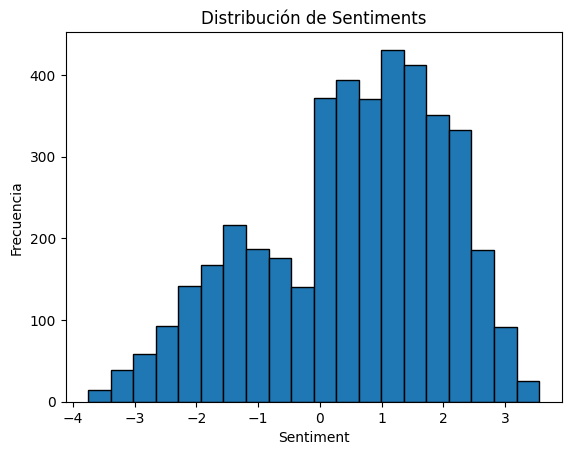

In [6]:
import matplotlib.pyplot as plt

plt.hist(GroundTruthTweets['sentiment'], bins=20, edgecolor='k')
plt.xlabel('Sentiment')
plt.ylabel('Frecuencia')
plt.title('Distribución de Sentiments')
plt.show()


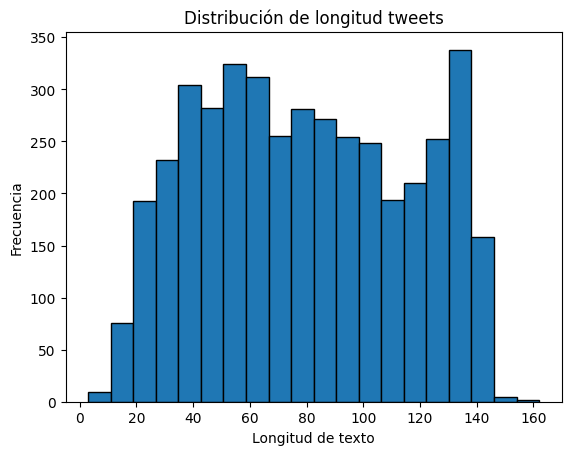

In [7]:
GroundTruthTweets['text_length'] = GroundTruthTweets['text'].apply(len)

plt.hist(GroundTruthTweets['text_length'], bins=20, edgecolor='k')
plt.xlabel('Longitud de texto')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitud tweets')
plt.show()


In [8]:
import re
import string

def clean_text(text):
    text = text.lower()  # Convertir a minúsculas
    text = re.sub(r'http\S+', '', text)  # Eliminar URLs
    text = re.sub(r'@\w+', '', text)  # Eliminar menciones
    text = re.sub(r'#\w+', '', text)  # Eliminar hashtags
    text = re.sub(r'[{}]'.format(string.punctuation), '', text)  # Eliminar puntuación
    text = re.sub(r'\d+', '', text)  # Eliminar números
    text = re.sub(r'\s+', ' ', text).strip()  # Eliminar espacios extra
    return text

In [9]:
GroundTruthTweets['clean_text'] = GroundTruthTweets['text'].apply(clean_text)
GroundTruthTweets.head()

,id,sentiment,text,text_length,clean_text
0,1,2.726316,Somehow I was blessed with some really amazing...,140,somehow i was blessed with some really amazing...
1,2,1.443299,Yay. Another good phone interview.,34,yay another good phone interview
2,3,2.873684,We were 17 deep last night &amp; the love was ...,136,we were deep last night amp the love was so st...
3,4,2.857143,"LMAO, AMAZING!",14,lmao amazing
4,5,-2.154639,Two words that should die this year: Sexting a...,70,two words that should die this year sexting an...


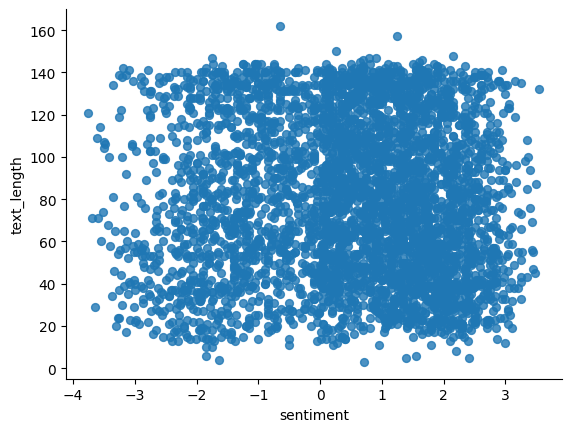

In [45]:
# @title sentiment vs text_length

from matplotlib import pyplot as plt
GroundTruthTweets.plot(kind='scatter', x='sentiment', y='text_length', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

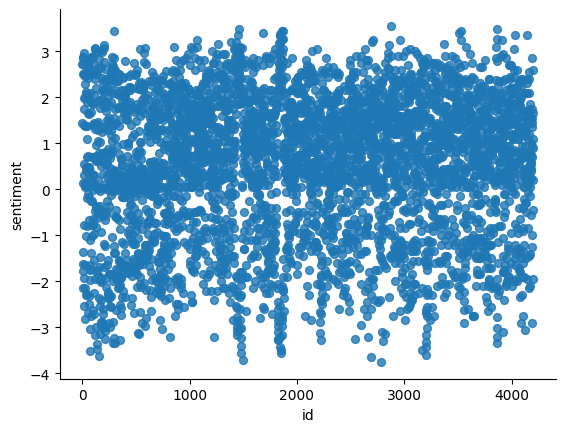

In [44]:
# @title id vs sentiment

from matplotlib import pyplot as plt
GroundTruthTweets.plot(kind='scatter', x='id', y='sentiment', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

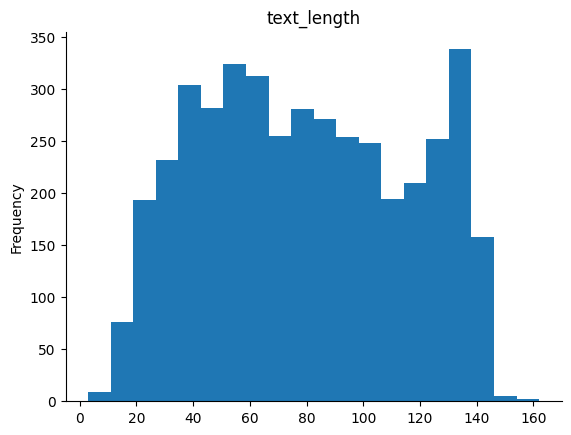

In [43]:
# @title text_length

from matplotlib import pyplot as plt
GroundTruthTweets['text_length'].plot(kind='hist', bins=20, title='text_length')
plt.gca().spines[['top', 'right',]].set_visible(False)

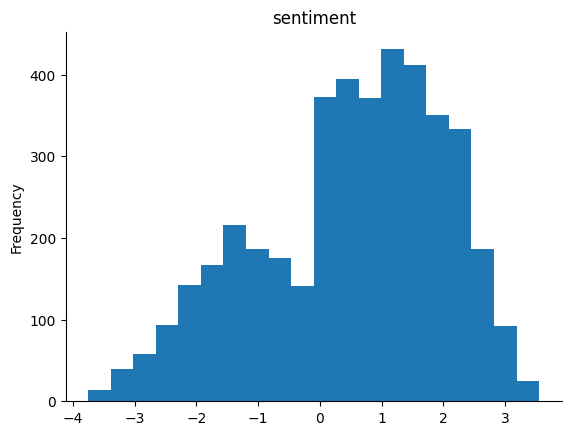

In [42]:
# @title sentiment

from matplotlib import pyplot as plt
GroundTruthTweets['sentiment'].plot(kind='hist', bins=20, title='sentiment')
plt.gca().spines[['top', 'right',]].set_visible(False)

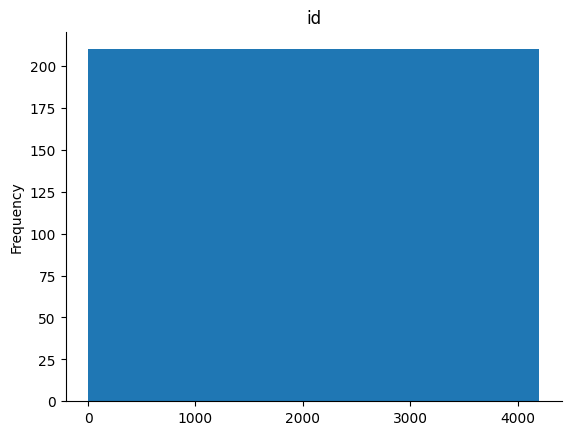

In [41]:
# @title id

from matplotlib import pyplot as plt
GroundTruthTweets['id'].plot(kind='hist', bins=20, title='id')
plt.gca().spines[['top', 'right',]].set_visible(False)

3. Investigue sobre los tipos de tokenizadores que tiene la librería nltk. En un comentario explique brevemente en que se basó para escoger el que consideró correcto. (5pts)

In [10]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word not in stop_words]
    return filtered_words



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Por qué  usé word_tokenize:
- Es versátil y preciso para tokenizar la mayoría de los textos en palabras individuales. Maneja bien la separación de palabras y signos de puntuación.

- Es fácil de implementar y suficientemente eficiente para tareas generales de procesamiento de lenguaje natural.

- Funciona bien con otros procesos de limpieza y transformación de texto, como la eliminación de stopwords y la lematización. Además, es una opción estándar y ampliamente utilizada en la comunidad de procesamiento de lenguaje natural.

In [11]:

GroundTruthTweets['tokens'] = GroundTruthTweets['clean_text'].apply(tokenize_and_remove_stopwords)
GroundTruthTweets.head()

,id,sentiment,text,text_length,clean_text,tokens
0,1,2.726316,Somehow I was blessed with some really amazing...,140,somehow i was blessed with some really amazing...,"[somehow, blessed, really, amazing, friends, l..."
1,2,1.443299,Yay. Another good phone interview.,34,yay another good phone interview,"[yay, another, good, phone, interview]"
2,3,2.873684,We were 17 deep last night &amp; the love was ...,136,we were deep last night amp the love was so st...,"[deep, last, night, amp, love, strong, everybo..."
3,4,2.857143,"LMAO, AMAZING!",14,lmao amazing,"[lmao, amazing]"
4,5,-2.154639,Two words that should die this year: Sexting a...,70,two words that should die this year sexting an...,"[two, words, die, year, sexting, jeggings, die..."


4. Cree un modelo para determinar los sentimientos de cada uno de los textos en la base de datos, partiendo de lo obtenido a través de la tokenización. Responda: (15pts)
  1. ¿Qué tipo de problema de Machine Learning es?

Es un problema de clasificación supervisada. Con los textos se tratará de predecir categoría/clase del sentimiento.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorizar el texto limpio
tfidf = TfidfVectorizer(max_features=1000)  # Limitar a las 1000 características más importantes
X = tfidf.fit_transform(GroundTruthTweets['clean_text'])

# Convertir las etiquetas de sentimiento a clases
y = GroundTruthTweets['sentiment'].apply(lambda x: 'positive' if x > 0 else 'negative' if x < 0 else 'neutral')


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
from sklearn.linear_model import LogisticRegression

# Entrenar el modelo
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [15]:
from sklearn.metrics import classification_report, accuracy_score

# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el rendimiento
print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')


              precision    recall  f1-score   support

    negative       0.85      0.52      0.64       274
    positive       0.80      0.95      0.87       566

    accuracy                           0.81       840
   macro avg       0.82      0.74      0.76       840
weighted avg       0.82      0.81      0.80       840

Accuracy: 0.81


El modelo de clasificación de sentimientos tiene un rendimiento decente con una precisión global del 81%. Sin embargo, muestra un sesgo hacia la clase positiva, con un recall significativamente más bajo para la clase negativa. Las visualizaciones como la matriz de confusión y la curva ROC proporcionan una mejor comprensión del rendimiento del modelo y pueden ayudar a identificar áreas para mejorar, como abordar el desbalance de clases.

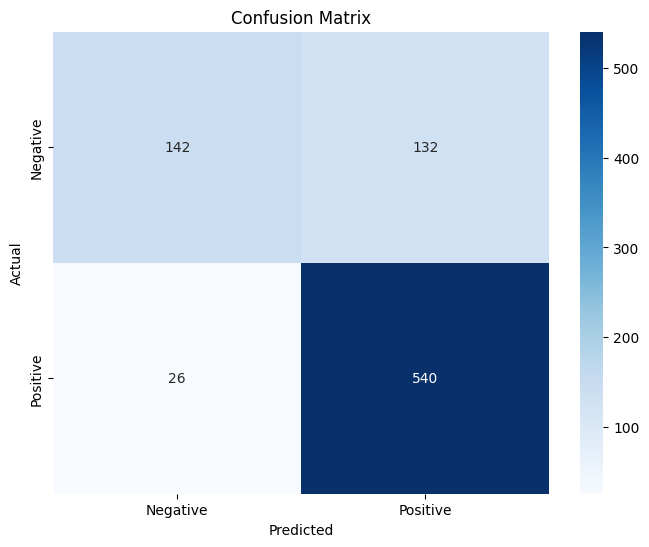

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


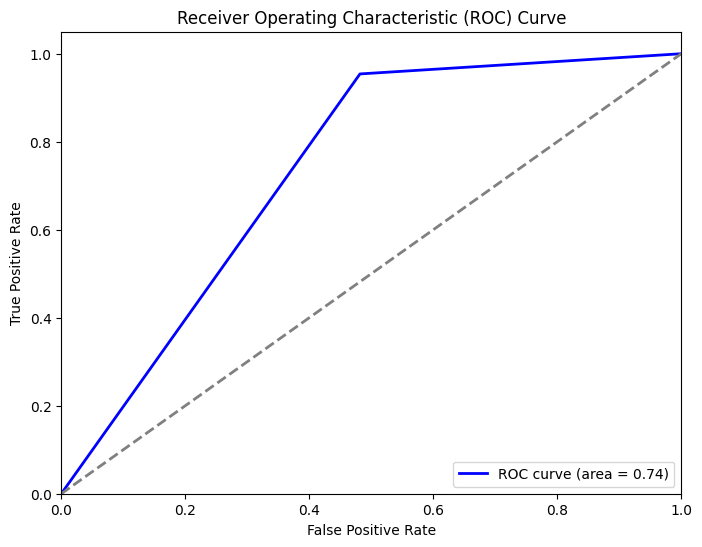

In [17]:
from sklearn.metrics import roc_curve, auc

# Binarizar las etiquetas
y_test_binarized = y_test.map({'negative': 0, 'positive': 1})
y_pred_binarized = pd.Series(y_pred).map({'negative': 0, 'positive': 1})

# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test_binarized, y_pred_binarized)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# Ahora, iteraré nuevamente para balancear las clases usando oversampling.

In [20]:
from imblearn.over_sampling import SMOTE

# Ajustar n_neighbors para SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [21]:
from imblearn.over_sampling import RandomOverSampler

# Aplicar RandomOverSampler para balancear las clases
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Dividir los datos resampleados en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Definir el modelo
model = LogisticRegression()

# Definir los hiperparámetros para la búsqueda de cuadrícula
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Realizar la búsqueda de cuadrícula
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_model = grid_search.best_estimator_

# Entrenar el mejor modelo
best_model.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = best_model.predict(X_test)


In [23]:
# Evaluar el rendimiento
print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')


              precision    recall  f1-score   support

    negative       0.85      0.88      0.87       581
     neutral       0.97      1.00      0.98       583
    positive       0.88      0.82      0.85       575

    accuracy                           0.90      1739
   macro avg       0.90      0.90      0.90      1739
weighted avg       0.90      0.90      0.90      1739

Accuracy: 0.90


In [24]:

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)


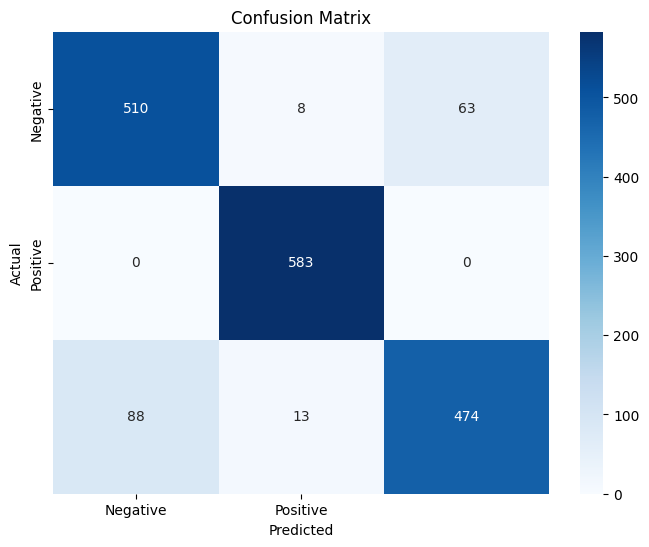

In [25]:

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Binarizar las etiquetas
y_test_binarized = y_test.map({'negative': 0, 'positive': 1})
y_pred_binarized = pd.Series(y_pred).map({'negative': 0, 'positive': 1})



El modelo ha mejorado significativamente después de aplicar técnicas de balanceo de clases y optimización de hiperparámetros. La precisión global del 90% y el equilibrio en las métricas por clase indican que el modelo es robusto y menos sesgado.

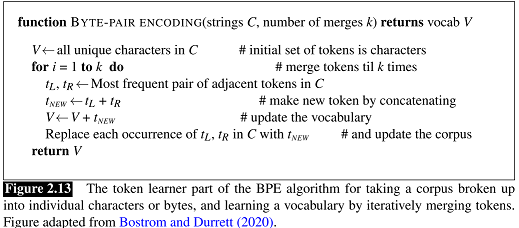

5. En La imagen anterior se muestra el algoritmo BPE visto en clase en seudo-código. El objetivo de este ejercicio es programarlo, desde 0, en Python. En este caso la calidad y limpieza del código si será tomada en cuenta.(60pts)

 Un detalle que no se menciono en clase es que los pares obtenidos pueden ser de la siguiente forma:
"bd" esta en el vocabulario. A través del proceso iterativo se ve que un el par más repetido es "bd" + "c", por lo tanto "bdc" entra al vocabulario. El pareo en BTE es por elementos del vocabulario, no por caracteres. Cometí el error de no hacer enfásis en eso durante la clase.

Este problema se encuentra fácilmente en internet. Pero los insto a retarse un poco a la hora de intentar resolverlo. Se presentarán situaciones donde la biblografía puede ser escasa, así que poder leer un algoritmo y programarlo es una habilidad importante.

In [32]:
import re
from collections import defaultdict, Counter

def preprocess_text(text):
    """Convierte el texto a minúsculas y elimina signos de puntuación."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Eliminar signos de puntuación
    return text

def get_vocab(corpus):
    """Crea el vocabulario inicial a partir del corpus."""
    vocab = Counter()
    for sentence in corpus:
        words = sentence.split()
        for word in words:
            vocab[' '.join(list(word)) + ' </w>'] += 1
    return vocab

def get_stats(vocab):
    """Obtiene las estadísticas de pares de tokens en el vocabulario."""
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    """Realiza el merge del par más frecuente en el vocabulario."""
    bigram = re.escape(' '.join(pair))
    pattern = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    new_vocab = {}
    for word in vocab:
        new_word = pattern.sub(''.join(pair), word)
        new_vocab[new_word] = vocab[word]
    return new_vocab

def byte_pair_encoding(corpus, num_merges):
    """Aplica el algoritmo de Byte-Pair Encoding (BPE) al corpus."""
    vocab = get_vocab(corpus)
    progress = []  # Lista para almacenar el progreso del vocabulario
    for i in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        vocab = merge_vocab(best_pair, vocab)
        progress.append(best_pair)  # Almacenar el par más frecuente de cada iteración
    return vocab, progress


In [33]:
#Texto que se debe tokenizar a través de BPE
text = "Imagina que intentas enseñar a leer a un niño. En lugar de introducirles directamente en párrafos complejos, empezaría introduciéndoles letras sueltas, luego sílabas y, por último, palabras enteras. De forma similar, la tokenización descompone grandes extensiones de texto en unidades más digeribles y comprensibles para las máquinas. El objetivo principal de la tokenización es representar el texto de forma que tenga sentido para las máquinas sin perder su contexto. Al convertir el texto en tokens, los algoritmos pueden identificar patrones más fácilmente. Este reconocimiento de patrones es crucial porque hace posible que las máquinas entiendan y respondan a la información humana. Por ejemplo, cuando una máquina encuentra la palabra correr, no la ve como una entidad singular, sino como una combinación de tokens que puede analizar y de la que puede extraer un significado."
corpus = text.split("¿Qué debería de poner aquí?")

In [34]:
# Preprocesar el texto
preprocessed_text = preprocess_text(text)

# Dividir el texto preprocesado en oraciones para formar el corpus
corpus = preprocessed_text.split(". ")

# Número de merges a realizar
num_merges = 50

# Aplicar BPE al corpus
final_vocab, progress = byte_pair_encoding(corpus, num_merges)

# Mostrar el progreso del vocabulario
print("Progreso del Vocabulario en cada iteración:")
for i, pair in enumerate(progress):
    print(f"Iteración {i+1}: {pair}")

# Mostrar el vocabulario final
print("\nVocabulario final:")
for word in final_vocab:
    print(f"{word}: {final_vocab[word]}")

Progreso del Vocabulario en cada iteración:
Iteración 1: ('s', '</w>')
Iteración 2: ('e', 'n')
Iteración 3: ('a', '</w>')
Iteración 4: ('e', '</w>')
Iteración 5: ('o', '</w>')
Iteración 6: ('i', 'n')
Iteración 7: ('r', '</w>')
Iteración 8: ('a', 's</w>')
Iteración 9: ('en', 't')
Iteración 10: ('e', 's</w>')
Iteración 11: ('q', 'u')
Iteración 12: ('d', 'e</w>')
Iteración 13: ('c', 'i')
Iteración 14: ('c', 'o')
Iteración 15: ('n', '</w>')
Iteración 16: ('a', 'r</w>')
Iteración 17: ('p', 'a')
Iteración 18: ('qu', 'e</w>')
Iteración 19: ('t', 'r')
Iteración 20: ('r', 'e')
Iteración 21: ('co', 'm')
Iteración 22: ('p', 'o')
Iteración 23: ('l', 'a</w>')
Iteración 24: ('e', 'x')
Iteración 25: ('m', 'á')
Iteración 26: ('l', '</w>')
Iteración 27: ('en', '</w>')
Iteración 28: ('u', 'e')
Iteración 29: ('s', 'i')
Iteración 30: ('ex', 't')
Iteración 31: ('tr', 'o')
Iteración 32: ('l', 'es</w>')
Iteración 33: ('f', 'o')
Iteración 34: ('n', 'd')
Iteración 35: ('y', '</w>')
Iteración 36: ('e', 'r')
Ite

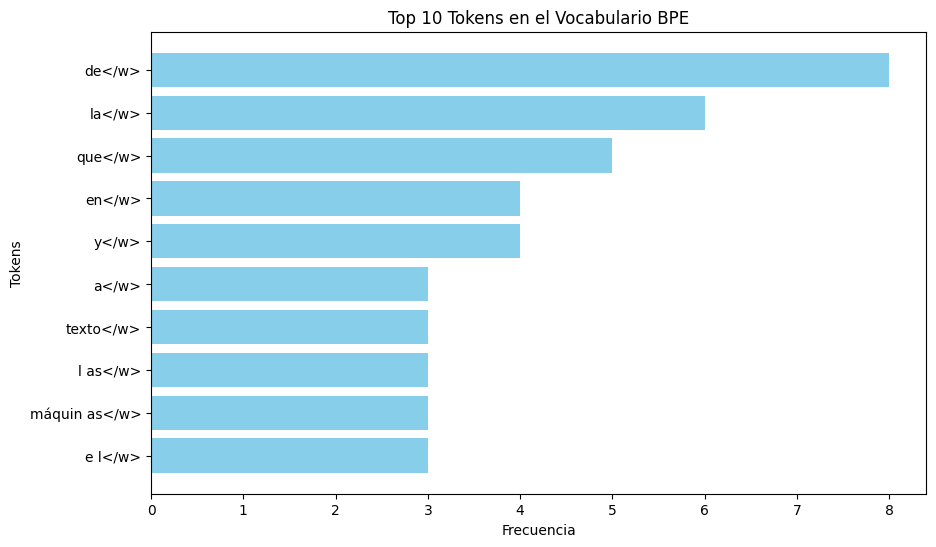

In [38]:
import matplotlib.pyplot as plt

def plot_top_tokens(vocab, top_n=10):
    """Grafica los top_n tokens más frecuentes en el vocabulario."""
    tokens = list(vocab.keys())
    frequencies = list(vocab.values())

    # Ordenar los tokens por frecuencia
    sorted_tokens = sorted(zip(tokens, frequencies), key=lambda x: x[1], reverse=True)
    top_tokens, top_frequencies = zip(*sorted_tokens[:top_n])

    # Eliminar el símbolo </w> para una mejor visualización
    top_tokens = [token.replace(' </w>', '') for token in top_tokens]

    plt.figure(figsize=(10, 6))
    plt.barh(top_tokens, top_frequencies, color='skyblue')
    plt.xlabel('Frecuencia')
    plt.ylabel('Tokens')
    plt.title(f'Top {top_n} Tokens en el Vocabulario BPE')
    plt.gca().invert_yaxis()  # Invertir el eje y para que el token más frecuente esté arriba
    plt.show()

# Graficar el top 10 del vocabulario final
plot_top_tokens(final_vocab, top_n=10)


### Referencias:

Bostrom, K., & Durrett, G. (2020). Byte Pair Encoding is Suboptimal for Language Model Pretraining. In Findings of the Association for Computational Linguistics: EMNLP 2020 (pp. 4617-4624). Association for Computational Linguistics. DOI: 10.18653/v1/2020.findings-emnlp.414

Sennrich, R., Haddow, B., & Birch, A. (2016). Neural Machine Translation of Rare Words with Subword Units. Proceedings of the 54th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers), 1715-1725. DOI: 10.18653/v1/P16-1162

Kudo, T. (2018). Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates. Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers), 66-75. DOI: 10.18653/v1/P18-1007

### Ahora bien, partiendo de los papers que leímos en clase, me llamó el tema de unigramas. Se me ocurre que se puede comparar para ver como actúa en comparación del BPE.


In [46]:

def get_initial_vocab(corpus):
    """Crea el vocabulario inicial a partir del corpus."""
    vocab = Counter()
    for sentence in corpus:
        words = sentence.split()
        for word in words:
            for i in range(len(word)):
                for j in range(i+1, len(word)+1):
                    vocab[word[i:j]] += 1
    return vocab

def compute_cost(vocab):
    """Calcula el costo del vocabulario."""
    total_count = sum(vocab.values())
    cost = {token: - (count / total_count) for token, count in vocab.items()}
    return cost

def unigram_tokenize(corpus, num_iterations=50):
    """Aplica el algoritmo de tokenización por Unigramas al corpus."""
    vocab = get_initial_vocab(corpus)
    cost = compute_cost(vocab)

    for _ in range(num_iterations):
        # Seleccionar el token con el menor costo
        min_cost_token = min(cost, key=cost.get)

        # Reemplazar el token en el corpus
        new_vocab = Counter()
        for sentence in corpus:
            sentence = sentence.replace(min_cost_token, f" {min_cost_token} ")
            words = sentence.split()
            for word in words:
                for i in range(len(word)):
                    for j in range(i+1, len(word)+1):
                        new_vocab[word[i:j]] += 1
        vocab = new_vocab
        cost = compute_cost(vocab)

    return vocab

In [47]:
final_vocab = unigram_tokenize(corpus, num_iterations=50)

# Mostrar el vocabulario final
print("Vocabulario final del modelo de Unigramas:")
for token, freq in final_vocab.most_common(10):
    print(f"{token}: {freq}")

Vocabulario final del modelo de Unigramas:
e: 98
a: 75
n: 68
o: 53
i: 52
r: 49
s: 48
t: 39
l: 37
u: 30


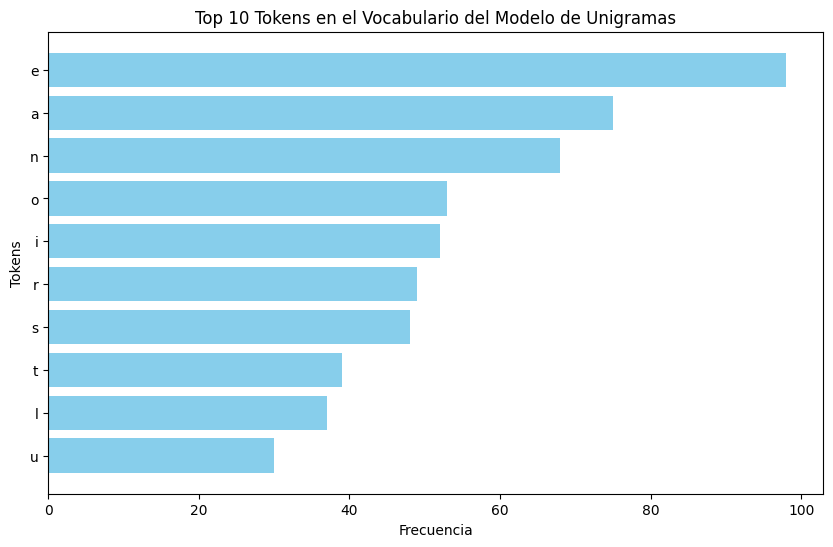

In [48]:
def plot_top_tokens_unigram(vocab, top_n=10):
    """Grafica los top_n tokens más frecuentes en el vocabulario del modelo de Unigramas."""
    tokens = list(vocab.keys())
    frequencies = list(vocab.values())

    # Ordenar los tokens por frecuencia
    sorted_tokens = sorted(zip(tokens, frequencies), key=lambda x: x[1], reverse=True)
    top_tokens, top_frequencies = zip(*sorted_tokens[:top_n])

    plt.figure(figsize=(10, 6))
    plt.barh(top_tokens, top_frequencies, color='skyblue')
    plt.xlabel('Frecuencia')
    plt.ylabel('Tokens')
    plt.title(f'Top {top_n} Tokens en el Vocabulario del Modelo de Unigramas')
    plt.gca().invert_yaxis()  # Invertir el eje y para que el token más frecuente esté arriba
    plt.show()

# Graficar el top 10 del vocabulario final del modelo de Unigramas
plot_top_tokens_unigram(final_vocab, top_n=10)


Kudo, T. (2018). Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates. Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers), 66-75. DOI: 10.18653/v1/P18-1007

Hugging Face. (s.f.). Summary of the tokenizers. Hugging Face Documentation. Recuperado de Hugging Face

Bostrom, K., & Durrett, G. (2020). Byte Pair Encoding is Suboptimal for Language Model Pretraining. In Findings of the Association for Computational Linguistics: EMNLP 2020 (pp. 4617-4624). Association for Computational Linguistics. DOI: 10.18653/v1/2020.findings-emnlp.414